<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week5/diabetes_DL_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week2/diabetes.csv'

df = pd.read_csv(path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## 결측치 확인

In [3]:
# 결측치 확인
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Outlier(이상치) 확인

/tmp/ipykernel_3059/1365606354.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Glucose", data=df, palette="Set3")


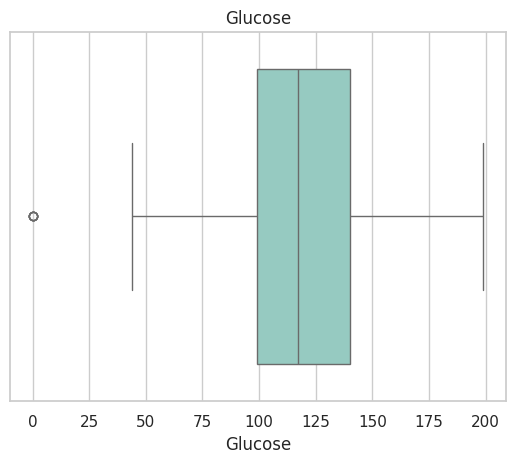

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.boxplot(x="Glucose", data=df, palette="Set3")
plt.title("Glucose")
plt.show()

In [5]:
y = df['Outcome']
print(y.value_counts())
y.head()

Outcome
0    500
1    268
Name: count, dtype: int64


,Outcome
0,1
1,0
2,1
3,0
4,1


In [6]:
X = df.drop('Outcome', axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


## 1. 데이터 형태 변환 + One-Hot Encoding + 데이터 분할 + Scaling

- 근데, diabetes인 경우, **Binary Classification**이다. 이럴 때는 **One-Hot-Encoding이 필요 없다.**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.values # numpy 배열로 전환
Y = y.values # One-Hot Encoding 이후, numpy 배열로 전환

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=y
) # 데이터 분할

scaler = StandardScaler() # 스케일러 객체 생성
X_train = scaler.fit_transform(X_train) # 학습(Train)데이터를 통해 학습(fit) 후에 적용(transform)
X_test = scaler.transform(X_test) # 테스트 데이터는 제외해서 학습(데이터 누수를 막기 위해)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614,) (154,)


## 2. 딥러닝 모델 생성, 학습, 평가

In [8]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 shape는 입력 열 개수(현재 8)
    layers.Dense(64, activation='relu'), # 은닉층(64개)
    layers.Dropout(0.3), # Dropout으로 랜덤하게 뉴런의 30% 을 제외시킴(끔). overfitting을 막기 위함.
    layers.Dense(32, activation='relu'), # 은닉층(32개)
    layers.Dense(1, activation='sigmoid') #출력층 (y_train.shape[1]만큼 출력함.(현재 2))
    # binary classification이므로 activation이 sigmoid
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # binary_crossentropy
    metrics=['accuracy'] # Classification이므로 metrics가 accurancy이다.
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6049 - loss: 0.6703 - val_accuracy: 0.7073 - val_loss: 0.6043
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7556 - loss: 0.5516 - val_accuracy: 0.7236 - val_loss: 0.5720
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.5238 - val_accuracy: 0.7317 - val_loss: 0.5664
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7658 - loss: 0.5018 - val_accuracy: 0.7154 - val_loss: 0.5692
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7719 - loss: 0.4861 - val_accuracy: 0.7642 - val_loss: 0.5643
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7556 - loss: 0.4813 - val_accuracy: 0.7642 - val_loss: 0.5714
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7780 - loss: 0.4679 - val_accuracy: 0.7480 - val_loss: 0.5801
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7923 - loss: 0.4556 - val_accuracy: 0.7480 - val_loss

## 3. 예측 및 평가

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

y_pred_class = (y_pred >= 0.5).astype(int).ravel()
y_test_class = y_test.ravel()



print(classification_report(y_test_class, y_pred_class))
print(confusion_matrix(y_test_class, y_pred_class))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       100
           1       0.81      0.72      0.76        54

    accuracy                           0.84       154
   macro avg       0.84      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154

[[91  9]
 [15 39]]


# 위 코드 설명
## `.ravel()`
- `.ravel()`은 `.flatten()`과 비슷하게 배열을 1차원 벡터로 핀다.
- 차이는 다음과 같다.
  - `ravel()`
    - 가능하면 **원본을 그대로 펼쳐서** 반환
    - 메모리 효율이 더 좋음
  - `flatten()`
    - 항상 **복사본**을 만들어서 반환
    - 기능 상 문제는 없음
### `y_pred_class = (y_pred >= 0.5).astype(int).ravel()`
- 왜 `(y_pred >= 0.5)`가 있을까?

  `model.predict(X_test)`의 결과 `y_pred`는 보통 다음과 같다.<br>(`activation='sigmoid'`였기 때문. `sigmoid`의 출력은 확률이다.)
  ```python
  [[0.12],
  [0.83],
  [0.44],
  [0.91]]
  ```
  이 값들은 **"1일 가능성"** 을 나타내는 값들이다. 이때 기준이 0.5이다.
  - 0.5 이상이면 → `True` → `1`
  - 0.5 미만이면 → `False` → `0`

## `y_test_class = y_test.ravel()`
- 반면, y_test는
그래도 혹시 모르니, `y_test_class = y_test.ravel())` 를 쓴다.

## 4. 학습 과정 시각화

In [10]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

## 손실 그래프

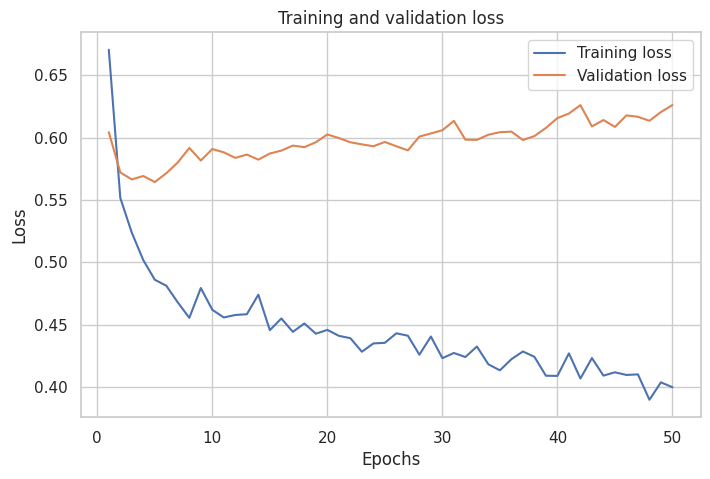

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 정확도 그래프

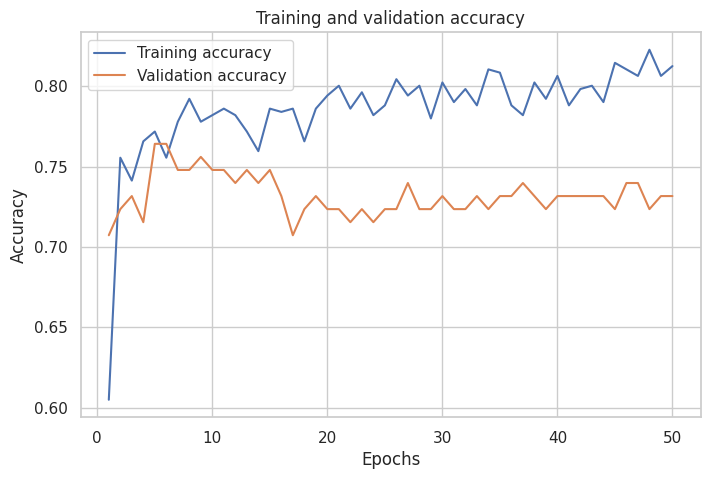

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 결과
- 생각 보다.. 과적합이 일어나고 있다.
- 이유를 모르겠다.. 왜 이러지?

이럴 땐, 챗지피티...
이유는 다음과 같다고 한다.

---

# 성능이 기대보다 낮게 느껴지는 이유

현재 결과는 **생각보다 아주 나쁜 수준은 아니다.**  
오히려 이 데이터셋 기준으로는 **나쁘지 않은 편**이다.

### 현재 결과
- **accuracy = 0.86**
- class 1(당뇨)의 **recall = 0.72**

### confusion matrix 해석
- **TN = 93**
- **FP = 7**
- **FN = 15**
- **TP = 39**

즉, 전체 정확도는 괜찮지만,  
**양성(class 1, 당뇨)을 놓치는 경우(FN)가 조금 있어서 체감상 성능이 아쉽게 느껴질 수 있다.**

---

## 왜 기대보다 덜 좋아 보이는가?

### 1. 데이터셋 자체가 작다
이 데이터셋은 샘플 수가 **768개**로 크지 않다.

- feature 수: 8개
- sample 수: 768개

이 정도 크기에서는 딥러닝이 압도적으로 유리하지 않다.  
오히려 **로지스틱 회귀(Logistic Regression)** 나 **트리 기반 모델**이 비슷하거나 더 좋은 성능을 내는 경우도 많다.

---

### 2. 클래스 불균형이 있다
레이블 분포를 보면:

- class 0: 500개
- class 1: 268개

즉, **0이 더 많다.**

이 경우 모델은 자연스럽게 **0을 더 잘 맞추는 방향**으로 학습되기 쉽다.  
그래서 다음과 같은 현상이 나타난다.

- class 0 recall = 높음
- class 1 recall = 상대적으로 낮음

즉, **accuracy는 괜찮아 보여도 실제로는 class 1을 놓치는 비율이 존재할 수 있다.**

---

### 3. 이 데이터셋의 중요한 특징: 0이 결측치 역할을 하는 컬럼들이 있다
`isnull().sum()`만 보면 결측치가 없어 보일 수 있다.  
하지만 이 데이터셋은 보통 다음 컬럼들에서 **0이 실제 결측치처럼 들어 있는 경우**가 많다.

대표적인 컬럼:
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

이 값들이 0인 것은 실제 의미상 비정상적인 경우가 많으므로,<br>(예를 들어, 혈당이 0, BMI가 0, 인슐린 수치가 0인건 불가능한데, 이러한 데이터가 실제로 있음.)<br>
그냥 0으로 두면 모델 성능이 떨어질 수 있다.

### 확인 코드
```python
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols] == 0).sum())
```

---

### 4. 모델이 데이터 크기에 비해 약간 크다
현재 모델 구조는 다음과 같다.

~~~text
Dense(64) -> Dropout(0.3) -> Dense(32) -> Dense(1)
~~~

하지만:
- 데이터는 작고
- feature도 8개뿐인데
- 모델은 상대적으로 큰 편이다

이 경우 학습 데이터에는 점점 잘 맞지만,  
검증 데이터에는 오히려 성능이 떨어지는 **overfitting**이 생길 수 있다.

---

### 5. 학습 로그상 overfitting 신호가 보인다
학습 초반에는 validation loss가 감소하지만,  
어느 시점 이후에는 validation loss가 다시 증가하는 흐름이 나타난다.

즉,

- train accuracy는 계속 올라감
- validation loss는 증가함

이는 전형적인 **overfitting 신호**이다.

따라서 50 epoch까지 계속 학습하는 것이 꼭 좋은 것은 아니다.

---

## 개선 방법

### 1. 0 값을 결측치처럼 처리하기
다음 컬럼의 0은 `NaN`으로 바꾸고, 중앙값 등으로 대체하는 것이 좋다.

~~~python
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

for col in cols:
    df[col] = df[col].fillna(df[col].median())
~~~

이 전처리는 성능 개선에 꽤 중요할 수 있다.

---

### 2. EarlyStopping 사용하기
validation loss가 좋아지지 않으면 학습을 멈추도록 설정하면,  
불필요한 overfitting을 줄일 수 있다.

~~~python
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
~~~

~~~python
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[callback]
)
~~~

---

### 3. 모델을 더 단순하게 만들기
현재 데이터 크기에서는 더 작은 모델이 오히려 일반화 성능이 더 좋을 수 있다.

예시:

~~~python
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
~~~

---

### 4. accuracy만 보지 말고 recall, f1-score도 함께 보기
당뇨 예측에서는 **양성(class 1)을 놓치는 것**이 중요할 수 있으므로,  
accuracy만 보는 것은 한계가 있다.

같이 확인하면 좋은 지표:
- **recall**
- **precision**
- **f1-score**
- **ROC-AUC**

---

### 5. threshold(기준값) 조정하기
현재는 보통 다음과 같이 예측 클래스를 정한다.

~~~python
y_pred_class = (y_pred >= 0.5).astype(int)
~~~

하지만 class 1 recall을 높이고 싶다면 threshold를 조금 낮출 수 있다.

예:

~~~python
y_pred_class = (y_pred >= 0.4).astype(int).ravel()
~~~

이 경우 일반적으로:
- recall은 올라갈 수 있음
- precision은 떨어질 수 있음

즉, 목적에 따라 적절히 조정할 수 있다.

---

## 결론

현재 성능이 아주 이상한 것은 아니다.  
이 데이터셋에서 다음 정도면 크게 나쁜 결과는 아니다.

- accuracy 약 **0.85 ~ 0.86**
- class 1 recall 약 **0.7대**

다만 성능이 아쉽게 느껴지는 이유는 다음과 같다.

1. **데이터셋이 작다**
2. **클래스 불균형이 있다**
3. **0값 결측치 처리가 안 되었을 가능성이 크다**
4. **모델이 약간 커서 overfitting이 생길 수 있다**

---

## 가장 먼저 해볼 것 3가지

1. **0값을 결측치처럼 처리하기**
2. **EarlyStopping 추가하기**
3. **모델을 더 단순하게 줄이기**